# Playground

In [ ]:
# position as array or dict
position = {'x': 0, 'y': 0, 'z': 0}
poi_manager_logic.move_scanner(position)

## Get confocal image

In [15]:
import matplotlib.pyplot as plt
import numpy as np

In [31]:
scan_data = scanning_data_logic.get_current_scan_data()

In [32]:
source = 'APD1'

data = scan_data.data[source]
(xrange,yrange) = scan_data.scan_range

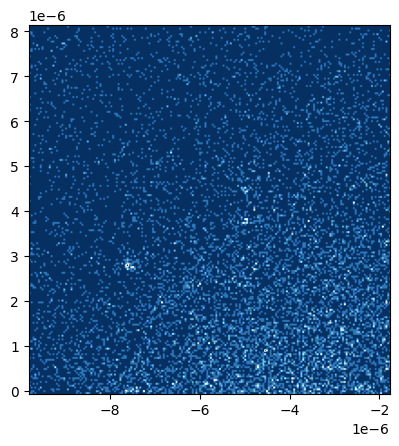

In [33]:
imgdata = np.fliplr(np.array(data)).transpose() # scudi displayes in a weird way.
extent=[xrange[0],xrange[1],yrange[0],yrange[1]]
plt.imshow(imgdata, extent=extent, cmap='RdBu_r')

## Vlads code to change resonant laser freq

In [12]:
ple_gui

<qudi.gui.ple.ple_gui.PLEScanGui(0x2b040b5c9b0) at 0x000002B041918580>

In [13]:
scanner_gui

<qudi.gui.scanning.scannergui.ScannerGui(0x2b039f73e80) at 0x000002B037D4B780>

In [14]:
ws_wavemeter

<qudi.hardware.wavemeter.ws_wavemeter.HighFinesseWavemeter(0x1fbbf8203e0) at 0x000001FBC319F800>

In [15]:
scanning_probe_logic

<qudi.logic.scanning.probe_logic.ScanningProbeLogic(0x2b039f739a0) at 0x000002B036411B40>

In [1]:
wavelengthset_laser_offset

NameError: name 'wavelength' is not defined

In [2]:

# %%
import time
import numpy as np
import json
import os
from toptica.lasersdk.dlcpro.v2_0_3 import DLCpro,LaserHead,  NetworkConnection, DeviceNotFoundError
def go_to_ple_target(target):
    ple_gui._mw.ple_widget.target_point.setValue(target)
    ple_gui._mw.ple_widget.target_point.sigPositionChangeFinished.emit(target)
    #laser_scanner_logic.set_target_position({"a": target})
    time.sleep(0.5)

def save_scan(name):
    scanner_gui.save_path_widget.saveTagLineEdit.setText(name)
    scanner_gui.scan_2d_dockwidgets[('x', 'y')].scan_widget.save_scan_button.clicked.emit() #saving
    dir_ = scanning_data_logic.module_default_data_dir
    return name, dir_

#to be rapaired:
def set_laser_offset(v):
    with DLCpro(NetworkConnection(dl_pro.tcp_address)) as dlc:
        dlc._laser1.dl.pc.voltage_set.set(v)


In [ ]:
ws_wavemeter.start_acquisition()
# %%
# Parameters
start_freq = 0  # GHz to Hz
end_freq = 18500  # GHz to Hz
step = 5000 #100  # GHz to Hz
num_steps = int((end_freq - start_freq) / step) + 1  # +1 for inclusive range
#resolution = (150, 150)  # x, y points

w0 = 484.130 #THz
# Data structure for results
frequencies = np.linspace(start_freq, end_freq, num_steps)

scan_names = {}
experiment_name = "resonant-confocal"
# Loop through frequencies
for i, freq in enumerate(frequencies):
    # Set laser frequency
    go_to_ple_target(freq)
    time.sleep(3)

    # Measure and record wavelength
    wavelength = (ws_wavemeter.get_current_wavelength() - w0) * 1e3   # to GHz
    print(wavelength)

    # Start scan and save data
    scanning_probe_logic.toggle_scan(True, ('x', 'y'))
    while scanning_probe_logic.module_state()=='locked':
            time.sleep(1)
    
    name, dir_ = save_scan(f"{experiment_name}_{i}_{wavelength:.2f}GHz")
    scan_names.update({wavelength: os.path.join(dir_, name)})

    print(f"Scan {i+1}/{num_steps} completed for {wavelength:.2f} GHz")

with open(f"{experiment_name}.txt", 'w') as file:
    json.dump(scan_names, file, indent=4)

# %%
ws_wavemeter.start_acquisition()
(ws_wavemeter.get_current_wavelength() - 484.130) * 1e3

# %%

# Process data (replace with your specific code)
# Here's an example using NumPy:
fluorescence_intensities = []
for data, _ in scan_data:
    # Assuming data is a 2D array of fluorescence intensities
    fluorescence_intensities.append(data.sum(axis=0))  # Sum along y-axis

# Create histograms (adapt binning as needed)
for i, intensity in enumerate(fluorescence_intensities):
    plt.hist(intensity, bins=50, label=f"{frequencies[i] / 1e9:.2f} GHz")

plt.xlabel("Fluorescence Intensity")
plt.ylabel("Count")
plt.title("Fluorescence Intensity at Different Frequencies")
plt.legend()
plt.show()


# Check offset between resonant and off resonant

In [8]:
import numpy as np
import time
import matplotlib.pyplot as plt

In [3]:
def do_optimize_and_wait():
    scanning_optimize_logic.start_optimize()
    while scanning_optimize_logic.module_state() == 'locked':
        time.sleep(1)
    optimal_position = scanning_optimize_logic.optimal_position
    return optimal_position

def turn_on_green(power = 80e3):
    # 80e3 are 80mW
    ibeam_smart.setPower(power)

def turn_off_green():
    ibeam_smart.setPower(0)

In [4]:
# Vlad magic to fix optimizer
scanning_optimize_logic._delay_next_sequence_step = 15
scanning_optimize_logic._optimize_spline_options = {
        "to_spline_2d": True,
        "s_2d": 1,
        "to_spline_1d": True,
        "s_1d": 1,
    }

# settings optimizer logic
settings = {
    'scan_frequency' : {'z': 5.0, 'x': 100.0, 'y': 100.0},
    'data_channel' : 'APD1',
    'scan_range' : {'z': 1.8e-06, 'x': 4e-07, 'y': 4e-07},
    'scan_resolution': {'z': 200, 'x': 25, 'y': 25},
    'scan_sequence': [('x', 'y'), 'z']
}
scanning_optimize_logic.set_optimize_settings(settings)

{'scan_frequency': {'z': 5.0, 'x': 100.0, 'y': 100.0}, 'data_channel': 'APD1', 'scan_range': {'z': 1.8e-06, 'x': 4e-07, 'y': 4e-07}, 'scan_resolution': {'z': 200, 'x': 25, 'y': 25}, 'scan_sequence': [('x', 'y'), ('z',)]}

In [7]:
coords_green = np.zeros(3)
coords_red = np.zeros(3)
for i in range(10):
    turn_on_green()
    _opt = do_optimize_and_wait()
    opt = np.array([float(_opt['x']),float(_opt['y']),float(_opt['z'])])
    coords_green = np.vstack((coords_green,opt))
    print('green')
    print(coords_green)
    turn_off_green()
    _opt = do_optimize_and_wait()
    opt = np.array([float(_opt['x']),float(_opt['y']),float(_opt['z'])])
    coords_red = np.vstack((coords_red,opt))
    print('red')
    print(coords_red)

green
[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-1.81512691e-08 -5.39908669e-06  1.86106216e-06]]
red
[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-1.25011166e-08 -5.40977794e-06  1.95209099e-06]]
green
[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-1.81512691e-08 -5.39908669e-06  1.86106216e-06]
 [-1.59255033e-08 -5.40047549e-06  1.90974865e-06]]
red
[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-1.25011166e-08 -5.40977794e-06  1.95209099e-06]
 [-9.45134653e-09 -5.40802166e-06  1.90073964e-06]]
green
[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-1.81512691e-08 -5.39908669e-06  1.86106216e-06]
 [-1.59255033e-08 -5.40047549e-06  1.90974865e-06]
 [-1.11442618e-08 -5.40684737e-06  1.82952883e-06]]
red
[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-1.25011166e-08 -5.40977794e-06  1.95209099e-06]
 [-9.45134653e-09 -5.40802166e-06  1.90073964e-06]
 [-2.62242350e-09 -5.40146280e-06  2.04124054e-06]]
green
[[ 0.00000000e+00  0.00000000e+00  0.000

In [ ]:
# coords_green = [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
# [-1.81512691e-08 -5.39908669e-06  1.86106216e-06]
# [-1.59255033e-08 -5.40047549e-06  1.90974865e-06]
# [-1.11442618e-08 -5.40684737e-06  1.82952883e-06]
# [-2.05469319e-08 -5.38524593e-06  2.03309189e-06]
# [-1.90723863e-08 -5.38167088e-06  1.98445135e-06]
# [-2.19087487e-08 -5.37961598e-06  1.99794144e-06]
# [-7.76273520e-09 -5.36210570e-06  2.07177387e-06]
# [-1.69062759e-08 -5.37110687e-06  2.09605135e-06]
# [-3.51968970e-08 -5.33262472e-06  2.24019550e-06]
# [-3.19011560e-08 -5.33016759e-06  2.27804234e-06]]

# coords_red = [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
# [-1.25011166e-08 -5.40977794e-06  1.95209099e-06]
# [-9.45134653e-09 -5.40802166e-06  1.90073964e-06]
# [-2.62242350e-09 -5.40146280e-06  2.04124054e-06]
# [-2.39039374e-08 -5.38198267e-06  2.05201892e-06]
# [-1.37417728e-08 -5.38511219e-06  2.05747297e-06]
# [-4.45747457e-09 -5.36457887e-06  2.07627838e-06]
# [-1.58719099e-08 -5.36153447e-06  2.14474685e-06]
# [-1.76755453e-08 -5.34930733e-06  2.25370901e-06]
# [-3.56750859e-08 -5.33683790e-06  2.23569550e-06]
# [-4.18681824e-08 -5.32877437e-06  2.17263694e-06]]

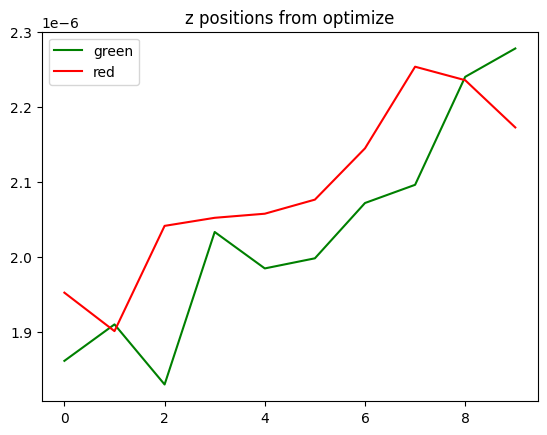

Text(0.5, 1.0, 'z red - z green, avg = 0.058474 um')

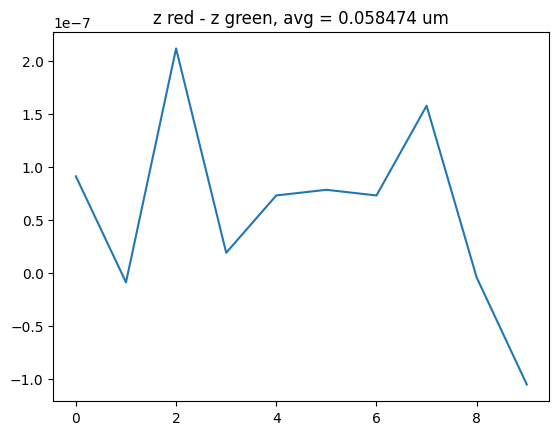

In [25]:
plt.plot(coords_green[1:,2],label='green', color='g')
plt.plot(coords_red[1:,2],label='red', color='r')
plt.legend()
plt.title('z positions from optimize')
plt.show()
plt.plot(coords_red[1:,2] - coords_green[1:,2])
plt.title('z red - z green, avg = %f um'%(1e6*np.mean(coords_red[1:,2] - coords_green[1:,2])))

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

: 

# Scanning code

In [ ]:
# bleaching
import time
for i in range(999):
    print(i)
    scanning_probe_logic.toggle_scan(True, ('x', 'y'))
    while scanning_probe_logic.module_state()=='locked':
            time.sleep(1)
    

## Fix optimizer

In [2]:
# Vlad magic to fix optimizer
scanning_optimize_logic._delay_next_sequence_step = 15
scanning_optimize_logic._optimize_spline_options = {
        "to_spline_2d": True,
        "s_2d": 1,
        "to_spline_1d": True,
        "s_1d": 1,
    }

# settings optimizer logic
settings = {
    'scan_frequency' : {'z': 5.0, 'x': 100.0, 'y': 100.0},
    'data_channel' : 'APD1',
    'scan_range' : {'z': 1.8e-06, 'x': 0.4e-6, 'y': 0.4e-6},
    'scan_resolution': {'z': 200, 'x': 25, 'y': 25},
    'scan_sequence': [('x', 'y'), 'z']
}
scanning_optimize_logic.set_optimize_settings(settings)

{'scan_frequency': {'z': 5.0, 'x': 100.0, 'y': 100.0}, 'data_channel': 'APD1', 'scan_range': {'z': 1.8e-06, 'x': 4e-07, 'y': 4e-07}, 'scan_resolution': {'z': 200, 'x': 25, 'y': 25}, 'scan_sequence': [('x', 'y'), ('z',)]}

## SCan

In [6]:
import time
import numpy as np
import json
import os
from toptica.lasersdk.dlcpro.v2_0_3 import DLCpro,LaserHead,  NetworkConnection, DeviceNotFoundError

In [7]:
def save_scan(name):
    scanner_gui.save_path_widget.saveTagLineEdit.setText(name)
    scanner_gui.scan_2d_dockwidgets[('x', 'y')].scan_widget.save_scan_button.clicked.emit() #saving
    dir_ = scanning_data_logic.module_default_data_dir
    return name, dir_

def set_laser_offset(v):
    with DLCpro(NetworkConnection(dl_pro.tcp_address)) as dlc:
        dlc._laser1.dl.pc.voltage_set.set(v)

def move_in_xy(xy_posi):
    x = xy_posi[0]
    y = xy_posi[1]
    z = poi_manager_logic.scanner_position[2]
    poi_manager_logic.move_scanner([x,y,z])
    return

def do_optimize_and_wait():
    scanning_optimize_logic.start_optimize()
    while scanning_optimize_logic.module_state() == 'locked':
        time.sleep(1)
    optimal_position = scanning_optimize_logic.optimal_position
    return optimal_position

def turn_on_green(power = 80e3):
    # 80e3 are 80mW
    ibeam_smart.setPower(power)

def turn_off_green():
    ibeam_smart.setPower(0)

In [8]:
ws_wavemeter.start_acquisition()

0

In [11]:
# Parameters 
# nice wl at 30V
start_voltage = 40  # V
end_voltage = 90  # V
step = 5 # V
num_steps = int((end_voltage - start_voltage) / step) + 1  # +1 for inclusive range
print('num steps = %d'%num_steps)

w0 = 484.130 #THz
# Data structure for results
voltages = np.linspace(start_voltage, end_voltage, num_steps)
print(voltages)

num steps = 11
[40. 45. 50. 55. 60. 65. 70. 75. 80. 85. 90.]


In [ ]:
scan_names = {}
experiment_name = "resonant-confocal"
# Loop through voltages
for i, voltage in enumerate(voltages):
    # Set laser frequency
    set_laser_offset(voltage)
    time.sleep(3)

    # Measure and record wavelength
    current_wl = ws_wavemeter.get_current_wavelength()
    print(current_wl)
    wavelength = (current_wl - w0) * 1e3   # to GHz
    print(wavelength)

    # turn on green
    turn_on_green()

    # go to good defect
    xy_posi = [-337.6e-9,-4.340e-6]
    move_in_xy(xy_posi) # improvement: do optimization once before, then always go to last opt posi

    # optimize on defect
    opt = do_optimize_and_wait()

    # turn off green
    turn_off_green()

    time.sleep(3)

    # Start scan and save data
    scanning_probe_logic.toggle_scan(True, ('x', 'y'))
    while scanning_probe_logic.module_state()=='locked':
            time.sleep(1)
    
    name, dir_ = save_scan(f"{experiment_name}_{i}_{wavelength:.2f}GHz")
    scan_names.update({wavelength: os.path.join(dir_, name)})

    print(f"Scan {i+1}/{num_steps} completed for {wavelength:.2f} GHz")

with open(f"{experiment_name}.txt", 'w') as file:
    json.dump(scan_names, file, indent=4)

484.1286624790672
-1.337520932793268


# Playground

In [4]:
turn_off_green()

In [5]:
turn_on_green()